# Smart Charging of an EV Taxi with Reinforcement Learning

An electric taxi driver charges at home. The vehicle **always arrives home at 2 p.m.
and leaves the garage at 4 p.m.**, every day. Instead of a flat charging rate, an
automated **charging agent** redecides the charging power **every 15 minutes**
(8 decisions in the 2-hour window). The power is bounded between `0 kW` and a
maximum rate (`22 kW`), and the battery capacity may not be exceeded.

When the taxi leaves at 4 p.m. it needs enough energy to complete its working day.
That **energy demand is stochastic** and drawn from a normal distribution, revealed
only at departure. The agent must:

1. **avoid running out of energy**, a shortfall at 4 p.m. carries a very high penalty;
2. **minimise the recharging cost**, which grows *exponentially* with the charging
   power and depends on a time-of-use price coefficient.

Per the task we (i) create the environment as **a very simple discrete-event
simulation** that receives the agent's decisions and returns the reward, (ii) define
a **Markov Decision Process** (states, actions, reward function), and (iii) solve it
with **reinforcement learning** (tabular Q-learning and a Deep Q-Network). To allow
discrete-action methods, charging is limited to the options *zero / low / medium / high*.

## Design choices (all parameters chosen for this study)

| Quantity | Symbol | Value |
|---|---|---|
| Charging window | — | 2 p.m. → 4 p.m. |
| Decision interval | $\Delta t$ | 15 min ($0.25$ h) → **8 steps** |
| Max charging power | $P_{\max}$ | 22 kW |
| Discrete power levels | — | zero / low / medium / high = $\{0,\tfrac13,\tfrac23,1\}\cdot P_{\max}$ |
| Usable battery capacity | $C$ | 50 kWh |
| Energy on arrival (2 p.m.) | $E_0$ | $\mathcal{U}(8, 18)$ kWh |
| Departure demand | $D$ | $\mathcal{N}(\mu{=}20,\ \sigma{=}5)$ kWh, clipped $\ge 0$ |
| Shortfall penalty | $\kappa$ | 10 per kWh not served |

## The Markov Decision Process

We specify the MDP as the tuple $(S, A, P, R, \gamma)$:

**States $S$**: what the agent observes before each decision:
$$s_t = \big(\; t/T,\;\; E_t/C \;\big)$$
the (normalised) time step and the current battery energy. The demand $D$ is *not*
part of the state, it is unknown until departure, so the agent must learn to hedge
against its distribution. Note that the battery energy is **continuous**: a
Q-*table* over $S$ only becomes possible after discretisation, which is
where abular methods meet their limits and function approximation (DQN)
takes over.

**Actions $A$**: one of four charging levels for the next 15 minutes:
$$a_t \in \{\text{zero},\text{low},\text{medium},\text{high}\}\ \Rightarrow\
p_t = f_a\,P_{\max},\quad f_a\in\{0,\tfrac13,\tfrac23,1\}.$$

**Transitions $P$**: deterministic energy accumulation, clipped at capacity:
$$E_{t+1} = \min\!\big(E_t + p_t\,\Delta t,\; C\big).$$

**Reward $R$**: the negative charging cost each step, plus a terminal shortfall
penalty. The recharging cost follows the exponential form given in the task,
$\text{cost}(t,p)=\sum_{t\in T}\alpha_t\,e^{p}$, which we render numerically with
the charging rate normalised to $f_a\in[0,1]$ (so that *not charging costs nothing*):
$$r_t = -\,\alpha_t\big(e^{f_a}-1\big)\qquad\text{and at departure}\qquad
r_T \mathrel{-}= \kappa\,\max(0,\; D-E_T).$$
Here $\alpha_t$ is the **time-of-use price coefficient** and it stays constant over time.

**Discount $\gamma$**: episodes are short (8 steps); we use $\gamma=0.99$, so the objective is the (near-undiscounted) expected episode return:
cover the demand almost always while paying as little as possible.

In [16]:
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import simpy                                       
import gymnasium as gym                             
from gymnasium import spaces
from gymnasium.wrappers import TransformReward
import torch                                        
from stable_baselines3 import DQN                   
from stable_baselines3.common.monitor import Monitor
%matplotlib inline

RANDOM_SEED = 42
GAMMA = 0.99

# ---- consistent, colour-blind-safe visual system -------------------------------
INK, MUTED, GRID = "#222222", "#666666", "#dcdcdc"
# Okabe-Ito (canonical CVD-safe) hues, assigned by entity (never cycled):
C_DQN, C_QL = "#0072B2", "#009E73"                          # the two learned agents
C_HIGH, C_FLAT, C_RANDOM = "#D55E00", "#E69F00", "#8a8a8a"  # the baselines
# ordinal charge levels zero->high as a single-hue sequential ramp (light->dark):
ACTION_COLORS = ["#f0f4fa", "#9ecae1", "#3182bd", "#08519c"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 10, "legend.frameon": False, "figure.facecolor": "white",
    "axes.facecolor": "white",
})
CLOCK = ["14:00","14:15","14:30","14:45","15:00","15:15","15:30","15:45"]

## The environment: a simple discrete-event simulation using the `gymnasium` API

Our home-charging day maps onto the following components:

* **Entity**: the taxi with its battery at the home charger.
* **Events**: arrival at 2 p.m., the eight decision epochs, and the departure at
  4 p.m., where the stochastic demand is realised.
* **Activity**: charging for one 15-minute slot at the commanded power, implemented
  as a SimPy *process* that `yield`s a `timeout`.
* **Resource**: the single home charger. With one vehicle there is no contention,
  so we deliberately do not need a capacity-limited `simpy.Resource` queue.

The SimPy environment owns the **clock** (in hours, starting at `14.0` - 2 p.m.),
and resetting means recreating the SimPy environment.

The learning agent sits *outside* and the
simulation must pause at every decision epoch and wait for an action.
`Gymnasium` API is the standard interface for exactly that, so we wrap the
simulation in a `gym.Env`: each `step(action)` hands the chosen power to the
charging activity and runs the SimPy clock until the slot completes. With
`verbose=True` the environment prints its **artificial history**, the
timestamped event log of one simulated day.

In [17]:
class SmartChargingEnv(gym.Env):
    """EV-taxi home charging: a very simple discrete-event simulation
    behind the standard gymnasium interface .

    Home 2 p.m. -> garage 4 p.m.  ==  2 h  ==  8 decision steps of 15 min each.
    reset() -> (obs, info) ;  step(a) -> (obs, reward, terminated, truncated, info).
    """

    # --- design parameters ---------------------------------------------------
    T = 8                        # decision steps (15 min each)
    DT = 0.25                    # hours per step
    HOME_ARRIVAL = 14.0          # 2 p.m. — the SimPy clock runs in hours
    P_MAX = 22.0                 # kW, highest charging rate
    CAPACITY = 50.0              # kWh usable battery
    E0_LOW, E0_HIGH = 8.0, 18.0  # random energy on arrival at home
    DEMAND_MU, DEMAND_SIGMA = 20.0, 5.0
    PENALTY_PER_KWH = 100.0       # steep penalty for running out of energy
    ACTION_FRACS = np.array([0.0, 1/3, 2/3, 1.0])   # zero / low / medium / high
    ACTION_LABELS = ["zero", "low", "medium", "high"]

    # --- Note: Here we have to make a design choice on how alpha behaves ---
    # time-of-use price coefficient alpha_t:
    # Constant alpha: 
    ALPHA = np.array([1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00])

    # ---- Other Examples -----
    # Decreasing Alpha_
    # ALPHA = np.array([1.00, 0.85, 0.70, 0.58, 0.48, 0.40, 0.33, 0.28])
    # Increasisng Alpha
    # ALPHA = np.array([0.28, 0.33, 0.40, 0.48, 0.58, 0.70, 0.85, 1])

    

    def __init__(self, verbose=False):
        super().__init__()
        self.action_space = spaces.Discrete(len(self.ACTION_FRACS))
        self.observation_space = spaces.Box(0.0, 1.0, shape=(2,), dtype=np.float32)
        self.verbose = verbose

    # --- the artificial history ----------------------------------------
    def _log(self, msg):
        if self.verbose:
            hours = int(self.sim.now)
            minutes = int(round((self.sim.now - hours) * 60))
            print(f"{hours:02d}:{minutes:02d}  {msg}")

    def _obs(self): # Normalized Time (which of the 8 decision slots) and normalized battery energy (state of charge as a fraction)
        return np.array([self.t / self.T, self.E / self.CAPACITY], dtype=np.float32)

    def _charge_slot(self, power):
        """Occupy the home charger for DT hours at `power` kW.
        A SimPy process that advances the event clock, then books the energy."""
        added = min(power * self.DT, self.CAPACITY - self.E)   # clip at capacity
        yield self.sim.timeout(self.DT)
        self.E += added
        return added

    # --- the gymnasium API ---------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)                    # seeds self.np_random
        # resetting == recreating the SimPy environment
        self.sim = simpy.Environment(initial_time=self.HOME_ARRIVAL)
        self.t = 0
        self.E = float(self.np_random.uniform(self.E0_LOW, self.E0_HIGH))
        self._log(f"taxi arrives home with {self.E:.1f} kWh in the battery")
        return self._obs(), {}

    def step(self, action):
        action = int(action)
        frac = self.ACTION_FRACS[action]
        power = frac * self.P_MAX
        self._log(f"decision {self.t + 1}/{self.T}: charge "
                  f"'{self.ACTION_LABELS[action]}' ({power:.1f} kW)")

        # run the DES until the charging activity for this slot has finished
        slot = self.sim.process(self._charge_slot(power))
        self.sim.run(until=slot)
        added = slot.value

        step_cost = self.ALPHA[self.t] * (np.exp(frac) - 1.0)   # exponential cost
        reward = -step_cost
        self.t += 1
        terminated = self.t >= self.T
        self._log(f"slot done: +{added:.2f} kWh -> battery {self.E:.1f} kWh "
                  f"| cost {step_cost:.3f}")

        info = {"step_cost": step_cost, "power": power, "added": added,
                "shortfall": 0.0, "demand": np.nan}
        if terminated:      # departure event — only now is the demand realised
            demand = max(0.0, float(self.np_random.normal(self.DEMAND_MU,
                                                          self.DEMAND_SIGMA)))
            shortfall = max(0.0, demand - self.E)
            penalty = self.PENALTY_PER_KWH * shortfall
            reward -= penalty
            info.update(shortfall=shortfall, demand=demand, penalty=penalty)
            self._log(f"taxi departs: demand {demand:.1f} kWh vs. battery "
                      f"{self.E:.1f} kWh -> shortfall {shortfall:.2f} kWh "
                      f"(penalty {penalty:.1f})")
        return self._obs(), float(reward), terminated, False, info

We can look into the action and observation spaces to get a feeling
for the problem, and sample random actions from the action space:

In [18]:
env_ref = SmartChargingEnv()

print("action space      :", env_ref.action_space)
print("5 sampled actions :", [int(env_ref.action_space.sample()) for _ in range(5)])
print("action labels     :", env_ref.ACTION_LABELS)
print("observation space :", env_ref.observation_space, " (normalised time, energy)")
print("max energy added per 15-min slot:", env_ref.P_MAX * env_ref.DT, "kWh")

action space      : Discrete(4)
5 sampled actions : [1, 3, 0, 0, 2]
action labels     : ['zero', 'low', 'medium', 'high']
observation space : Box(0.0, 1.0, (2,), float32)  (normalised time, energy)
max energy added per 15-min slot: 5.5 kWh


And here is one day's **artificial history** under a purely random policy
(`env.action_space.sample()`), the SimPy clock stamps every event:

In [19]:
demo_env = SmartChargingEnv(verbose=True)
obs, info = demo_env.reset(seed=RANDOM_SEED)
terminated, total = False, 0.0
while not terminated:
    action = demo_env.action_space.sample()      # random exploration
    obs, reward, terminated, truncated, info = demo_env.step(action)
    total += reward
print(f"\nepisode return under the random policy: {total:.2f}")

14:00  taxi arrives home with 15.7 kWh in the battery
14:00  decision 1/8: charge 'high' (22.0 kW)
14:15  slot done: +5.50 kWh -> battery 21.2 kWh | cost 1.718
14:15  decision 2/8: charge 'zero' (0.0 kW)
14:30  slot done: +0.00 kWh -> battery 21.2 kWh | cost 0.000
14:30  decision 3/8: charge 'low' (7.3 kW)
14:45  slot done: +1.83 kWh -> battery 23.1 kWh | cost 0.396
14:45  decision 4/8: charge 'zero' (0.0 kW)
15:00  slot done: +0.00 kWh -> battery 23.1 kWh | cost 0.000
15:00  decision 5/8: charge 'medium' (14.7 kW)
15:15  slot done: +3.67 kWh -> battery 26.7 kWh | cost 0.948
15:15  decision 6/8: charge 'medium' (14.7 kW)
15:30  slot done: +3.67 kWh -> battery 30.4 kWh | cost 0.948
15:30  decision 7/8: charge 'medium' (14.7 kW)
15:45  slot done: +3.67 kWh -> battery 34.1 kWh | cost 0.948
15:45  decision 8/8: charge 'low' (7.3 kW)
16:00  slot done: +1.83 kWh -> battery 35.9 kWh | cost 0.396
16:00  taxi departs: demand 14.8 kWh vs. battery 35.9 kWh -> shortfall 0.00 kWh (penalty 0.0)

epi

### The environment at a glance

The agent's trade-off is driven on the **how much** energy the trip will need (the demand
distribution). The agent never sees a demand draw before deciding and it only learns
its shape through the reward.

**Note: Actually the alpha t stays constant**

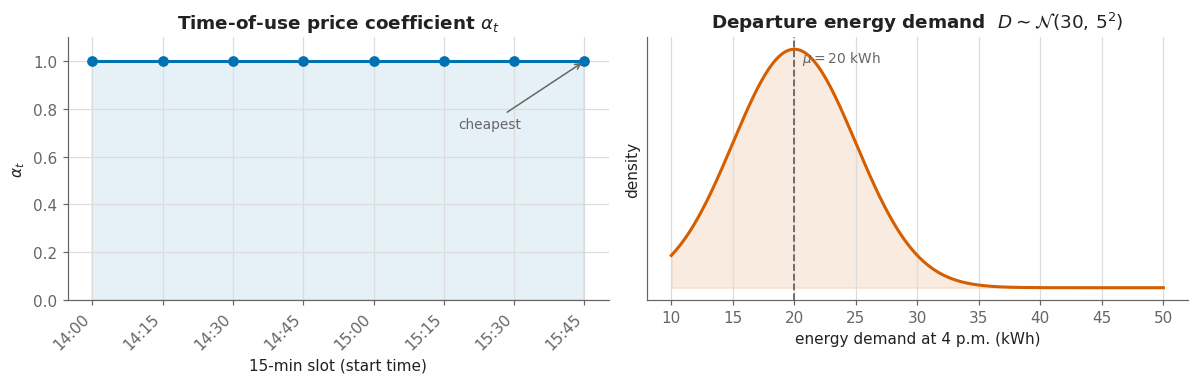

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

# (a) time-of-use price coefficient over the charging window
ax1.plot(range(env_ref.T), env_ref.ALPHA, color=C_DQN, lw=2, marker="o", ms=6,
         zorder=3)
ax1.fill_between(range(env_ref.T), env_ref.ALPHA, color=C_DQN, alpha=0.10, zorder=1)
ax1.set_xticks(range(env_ref.T)); ax1.set_xticklabels(CLOCK, rotation=45, ha="right")
ax1.set_ylim(0, 1.1)
ax1.set_title(r"Time-of-use price coefficient $\alpha_t$")
ax1.set_xlabel("15-min slot (start time)"); ax1.set_ylabel(r"$\alpha_t$")
ax1.annotate("cheapest", xy=(7, env_ref.ALPHA[-1]), xytext=(5.2, 0.72),
             color=MUTED, fontsize=9,
             arrowprops=dict(arrowstyle="->", color=MUTED))

# (b) departure demand distribution
x = np.linspace(10, 50, 400)
pdf = np.exp(-0.5 * ((x - env_ref.DEMAND_MU) / env_ref.DEMAND_SIGMA) ** 2) \
      / (env_ref.DEMAND_SIGMA * np.sqrt(2 * np.pi))
ax2.plot(x, pdf, color=C_HIGH, lw=2)
ax2.fill_between(x, pdf, color=C_HIGH, alpha=0.12)
ax2.axvline(env_ref.DEMAND_MU, color=MUTED, ls="--", lw=1.2)
ax2.text(env_ref.DEMAND_MU + 0.6, ax2.get_ylim()[1]*0.9,
         rf"$\mu={env_ref.DEMAND_MU:.0f}$ kWh", color=MUTED, fontsize=9)
ax2.set_title(r"Departure energy demand  $D\sim\mathcal{N}(30,\,5^2)$")
ax2.set_xlabel("energy demand at 4 p.m. (kWh)"); ax2.set_ylabel("density")
ax2.set_yticks([])
fig.tight_layout(); plt.show()

## Solver 1: tabular Q-learning

We use the off-policy TD-control algorithm which learns action values with the update
$$Q(S,A)\leftarrow Q(S,A)+\alpha\,[R+\gamma\max_{a^\prime}Q(S^\prime,a^\prime)-Q(S,A)]$$
following an $\varepsilon$-greedy behaviour policy with decaying $\varepsilon$. We
choose Q-learning over SARSA because it is **off-policy**: it learns the greedy
target policy regardless of the exploratory behaviour, which is also what makes the
experience replay of the DQN below legal.

A Q-*table* needs discrete states. Time is already discrete (8 slots) and we round the
battery energy to whole kWh, giving at most $8 \times 51$ states. We keep the table in a
`defaultdict` (terminal states are never acted from, so their entries stay at 0 and
the TD target needs no special casing) and track per-episode returns.

In [21]:
def discretize(obs):
    """Map the continuous observation onto a discrete state key (t, whole kWh)."""
    t = int(round(float(obs[0]) * SmartChargingEnv.T))
    e = int(round(float(obs[1]) * SmartChargingEnv.CAPACITY))
    return (t, e)

train_env = SmartChargingEnv()
num_actions = train_env.action_space.n

# --- Hyperparameters ---
num_episodes = 40_000
learning_rate = 0.1
gamma = GAMMA
epsilon = 1.0
min_epsilon = 0.05
epsilon_decay = 0.9999

# --- Initialization ---
Q_table = defaultdict(lambda: np.zeros(num_actions))
episode_returns_ql = []

np.random.seed(RANDOM_SEED)
obs, info = train_env.reset(seed=RANDOM_SEED)
train_env.action_space.seed(RANDOM_SEED)

print("Training tabular Q-learning agent...")
# --- Main Training Loop ---
for episode in range(num_episodes):
    obs, info = train_env.reset()
    state = discretize(obs)
    terminated = False
    total = 0.0

    while not terminated:
        # Choose action using the epsilon-greedy policy
        if np.random.random() < epsilon:
            action = train_env.action_space.sample()
        else:
            action = int(np.argmax(Q_table[state]))

        # Take the action
        obs, reward, terminated, truncated, info = train_env.step(action)
        next_state = discretize(obs)

        # --- The core Q-Learning update ---
        # 1. Find the max Q-value for the next state (the greedy choice)
        max_next_q = np.max(Q_table[next_state])
        # 2. Calculate the TD Target
        td_target = reward + gamma * max_next_q
        # 3. Calculate the TD Error and update
        td_error = td_target - Q_table[state][action]
        Q_table[state][action] = Q_table[state][action] + learning_rate * td_error

        state = next_state
        total += reward

    episode_returns_ql.append(total)
    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    if (episode + 1) % 5000 == 0:
        print(f"episode {episode + 1:6d} | eps {epsilon:.2f} | "
              f"mean return (last 1000): {np.mean(episode_returns_ql[-1000:]):8.3f}")

print("Training finished.")
print(f"states visited: {len(Q_table)}")

Training tabular Q-learning agent...
episode   5000 | eps 0.61 | mean return (last 1000):  -28.065
episode  10000 | eps 0.37 | mean return (last 1000):  -20.929
episode  15000 | eps 0.22 | mean return (last 1000):   -8.170
episode  20000 | eps 0.14 | mean return (last 1000):   -6.591
episode  25000 | eps 0.08 | mean return (last 1000):   -5.933
episode  30000 | eps 0.05 | mean return (last 1000):   -7.066
episode  35000 | eps 0.05 | mean return (last 1000):   -6.346
episode  40000 | eps 0.05 | mean return (last 1000):   -6.582
Training finished.
states visited: 271


### The learned Q-table

We visualises the state-value function $V(s)=\max_a Q(s,a)$ next to the greedy
action per state. Our state grid is (time slot × battery energy) instead of a 4×4
lake, but the reading is identical. States the $\varepsilon$-greedy agent never
visited are greyed out. Two behaviours emerge without
ever being programmed in:

* **charge more when the battery is low** (bottom rows) -> build enough of a buffer
  to cover the uncertain demand;
* **defer charging into the cheaper late slots** (right side) -> the top-up happens
  as late as the power limit allows

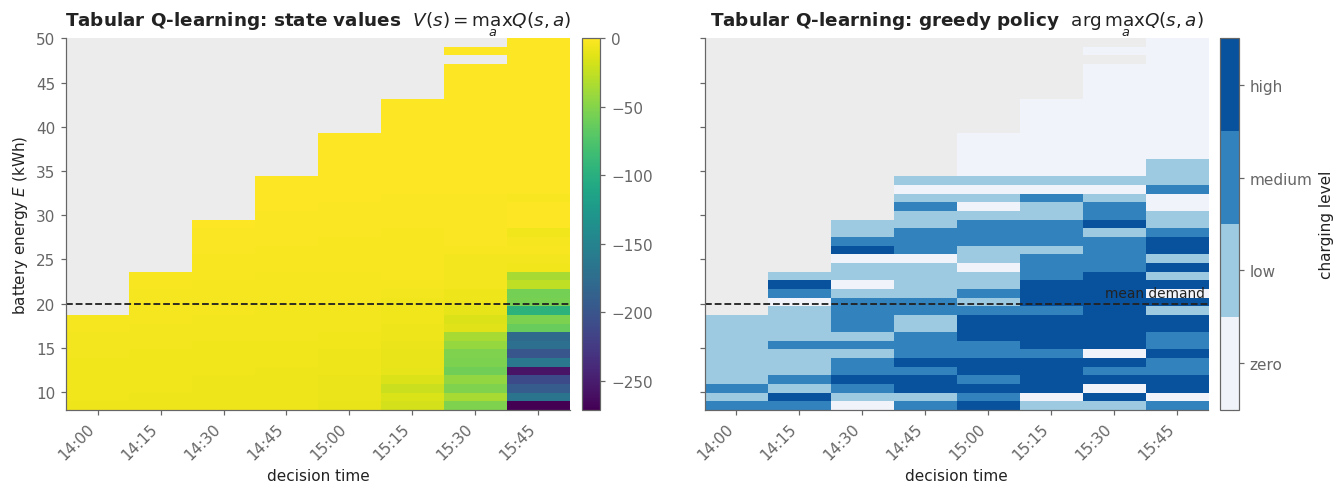

In [22]:
def plot_value_and_policy(V_grid, P_grid, e_values, agent_name):
    """ V(s)=max_a Q(s,a) heatmap next to the greedy policy."""
    T = SmartChargingEnv.T
    extent = [-0.5, T - 0.5, e_values[0], e_values[-1]]
    fig, (ax_v, ax_p) = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

    cmap_v = plt.cm.viridis.copy(); cmap_v.set_bad("#ececec")
    im_v = ax_v.imshow(np.ma.masked_invalid(V_grid), aspect="auto", origin="lower",
                       cmap=cmap_v, extent=extent)
    ax_v.set_title(f"{agent_name}: state values  $V(s)=\\max_a Q(s,a)$")
    fig.colorbar(im_v, ax=ax_v, pad=0.02)

    cmap_p = ListedColormap(ACTION_COLORS); cmap_p.set_bad("#ececec")
    im_p = ax_p.imshow(np.ma.masked_invalid(P_grid), aspect="auto", origin="lower",
                       cmap=cmap_p, vmin=-0.5, vmax=3.5, extent=extent)
    ax_p.set_title(f"{agent_name}: greedy policy  $\\arg\\max_a Q(s,a)$")
    cbar = fig.colorbar(im_p, ax=ax_p, ticks=[0, 1, 2, 3], pad=0.02)
    cbar.ax.set_yticklabels(SmartChargingEnv.ACTION_LABELS)
    cbar.set_label("charging level")

    for ax in (ax_v, ax_p):
        ax.set_xticks(range(T)); ax.set_xticklabels(CLOCK, rotation=45, ha="right")
        ax.axhline(SmartChargingEnv.DEMAND_MU, color=INK, ls="--", lw=1.2)
        ax.set_xlabel("decision time")
        ax.grid(False)
    ax_p.text(T - 0.55, SmartChargingEnv.DEMAND_MU + 0.7, "mean demand",
              ha="right", color=INK, fontsize=9)
    ax_v.set_ylabel("battery energy $E$ (kWh)")
    fig.tight_layout(); plt.show()


# --- build the tabular grids (whole-kWh bins; unvisited states are masked) ---
e_bins = np.arange(8, 51)
V_tab = np.full((len(e_bins), SmartChargingEnv.T), np.nan)
P_tab = np.full((len(e_bins), SmartChargingEnv.T), np.nan)
for i, e in enumerate(e_bins):
    for t in range(SmartChargingEnv.T):
        key = (t, int(e))
        if key in Q_table:                       # `in` does not create entries
            V_tab[i, t] = np.max(Q_table[key])
            P_tab[i, t] = np.argmax(Q_table[key])

plot_value_and_policy(V_tab, P_tab, e_bins, "Tabular Q-learning")

## Solver 2: Deep Q-Network with `stable_baselines3`

Discretising the battery works here, but it throws away structure: neighbouring
energy levels have almost identical values, yet every table cell must be learned
separately. A **Deep Q-Network** replaces the table with a neural network
$Q_\theta(s)$ that generalises across the continuous state.

For the scaling we use `gymnasium`'s `TransformReward` wrapper around SB3's
`Monitor`, so the recorded learning curve and the evaluation stays in
the original, unscaled units, only the learner sees rewards ×0.1.

In [23]:
REWARD_SCALE = 0.1

monitor_env = Monitor(SmartChargingEnv())      # records unscaled episode returns
dqn_train_env = TransformReward(monitor_env, lambda r: REWARD_SCALE * r)

model = DQN(
    "MlpPolicy", dqn_train_env,          # the exact WS 11 call, on our own env
    learning_rate=1e-3,
    buffer_size=20_000,
    learning_starts=500,
    batch_size=64,
    gamma=GAMMA,
    train_freq=1,
    target_update_interval=200,
    exploration_fraction=0.5,            # anneal eps 1.0 -> 0.05 over half of training
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[64, 64]),
    seed=RANDOM_SEED,
    verbose=0,
)
model.learn(total_timesteps=48_000)      # 8 steps/episode  ->  6,000 episodes

episode_returns_dqn = np.array(monitor_env.get_episode_rewards())
print(f"trained for {len(episode_returns_dqn)} episodes | "
      f"mean return (last 250): {episode_returns_dqn[-250:].mean():.3f}")

trained for 6000 episodes | mean return (last 250): -23.672


We put both agents' rolling-average
learning curves side by side.

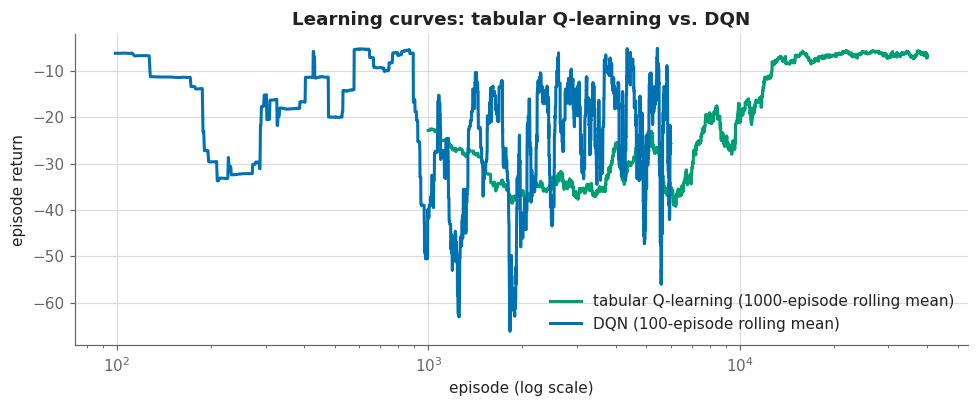

In [24]:
w_ql, w_dqn = 1000, 100
roll_ql = np.convolve(episode_returns_ql, np.ones(w_ql) / w_ql, mode="valid")
roll_dqn = np.convolve(episode_returns_dqn, np.ones(w_dqn) / w_dqn, mode="valid")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(range(w_ql - 1, len(episode_returns_ql)), roll_ql, color=C_QL, lw=2,
        label=f"tabular Q-learning ({w_ql}-episode rolling mean)")
ax.plot(range(w_dqn - 1, len(episode_returns_dqn)), roll_dqn, color=C_DQN, lw=2,
        label=f"DQN ({w_dqn}-episode rolling mean)")
ax.set_xscale("log")
ax.set_xlabel("episode (log scale)"); ax.set_ylabel("episode return")
ax.set_title("Learning curves: tabular Q-learning vs. DQN")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

### The DQN's value function and policy

We evaluated on a dense grid, because the
network answers *any* battery level, not just whole-kWh bins.

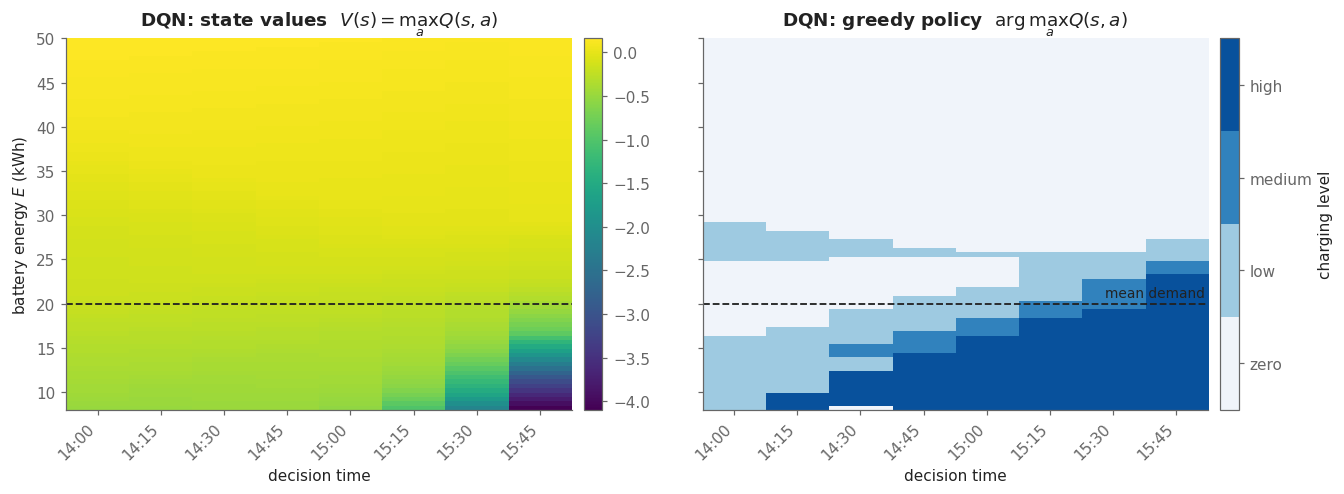

In [25]:
soc_fine = np.arange(8.0, 50.01, 0.5)
obs_grid = np.array([[t / SmartChargingEnv.T, e / SmartChargingEnv.CAPACITY]
                     for e in soc_fine for t in range(SmartChargingEnv.T)],
                    dtype=np.float32)
with torch.no_grad():
    q_grid = model.q_net(torch.as_tensor(obs_grid, device=model.device)).cpu().numpy()

V_dqn = q_grid.max(axis=1).reshape(len(soc_fine), SmartChargingEnv.T)
P_dqn = q_grid.argmax(axis=1).reshape(len(soc_fine), SmartChargingEnv.T).astype(float)

plot_value_and_policy(V_dqn, P_dqn, soc_fine, "DQN")

### Example charging schedules

Rolling the DQN's greedy policy forward from three different arrival states. Bars
are the **energy added per 15-min slot** (kWh); the line is the resulting **state of
charge**. The shaded band is the demand's $\mu\pm\sigma$ range that the schedule
must cover.

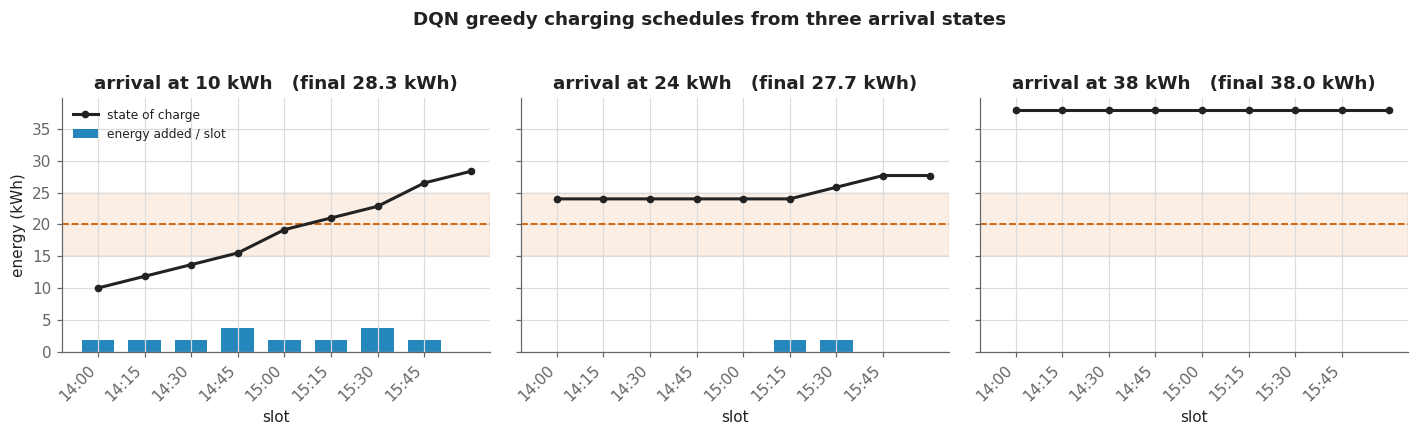

In [26]:
def rollout_greedy(start_e):
    env = SmartChargingEnv()
    env.reset(seed=0)
    env.t, env.E = 0, float(start_e)         # probe a chosen arrival state
    obs = env._obs()
    added, soc = [], [env.E]
    terminated = False
    while not terminated:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(
            int(np.asarray(action).reshape(-1)[0]))
        added.append(info["added"]); soc.append(env.E)
    return np.array(added), np.array(soc)

starts = [10.0, 24.0, 38.0]
T = SmartChargingEnv.T
mu, sd = SmartChargingEnv.DEMAND_MU, SmartChargingEnv.DEMAND_SIGMA
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, e0 in zip(axes, starts):
    added, soc = rollout_greedy(e0)
    ax.axhspan(mu - sd, mu + sd, color=C_HIGH, alpha=0.10)
    ax.axhline(mu, color=C_HIGH, ls="--", lw=1.2)
    ax.bar(range(T), added, color=C_DQN, alpha=0.85, width=0.7,
           label="energy added / slot")
    ax.plot(range(T + 1), soc, color=INK, lw=2, marker="o", ms=4,
            label="state of charge")
    ax.set_title(f"arrival at {e0:.0f} kWh   (final {soc[-1]:.1f} kWh)")
    ax.set_xticks(range(T)); ax.set_xticklabels(CLOCK, rotation=45, ha="right")
    ax.set_xlabel("slot")
axes[0].set_ylabel("energy (kWh)")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("DQN greedy charging schedules from three arrival states", y=1.03,
             fontweight="bold")
fig.tight_layout(); plt.show()

## Evaluation against baseline strategies

We compare the agents under identical
conditions,  here over 4,000 random days each, together with hand-crafted baselines:

* **Always high**: charge at 22 kW every slot (safe, but ignores price and over-charges);
* **Target-*X* flat**: charge at the constant rate needed to reach a fixed energy
  target by 4 p.m. (a strong, demand-aware heuristic — but blind to the price curve);
* **Random**: pick a level uniformly at random.

For each policy we report the mean charging cost, the fraction of days the demand
was fully **served**, the mean energy **shortfall**, and the mean **return**.

In [27]:
def policy_dqn(env, obs):
    action, _ = model.predict(obs, deterministic=True)
    return int(np.asarray(action).reshape(-1)[0])

def policy_ql(env, obs):
    return int(np.argmax(Q_table[discretize(obs)]))

def policy_always_high(env, obs):
    return 3

def policy_random(env, obs):
    return int(env.action_space.sample())

def make_target_policy(target_energy):
    """Charge at the constant power needed to reach `target_energy` by 4 p.m."""
    def pol(env, obs):
        remaining = env.T - env.t
        need_power = max(0.0, target_energy - env.E) / (remaining * env.DT) \
                     if remaining > 0 else 0.0
        frac = np.clip(need_power / env.P_MAX, 0, 1)
        return int(np.argmin(np.abs(env.ACTION_FRACS - frac)))
    return pol

def evaluate(policy, n=4000, seed=123):
    env = SmartChargingEnv()
    env.reset(seed=seed)                    # seed once, then continue the RNG stream
    env.action_space.seed(seed)
    costs, shortfalls, returns, served = [], [], [], []
    for _ in range(n):
        obs, _ = env.reset()
        terminated, cost, total, info = False, 0.0, 0.0, {}
        while not terminated:
            obs, r, terminated, truncated, info = env.step(policy(env, obs))
            cost += info["step_cost"]; total += r
        costs.append(cost); shortfalls.append(info["shortfall"]); returns.append(total)
        served.append(info["shortfall"] <= 1e-9)
    return dict(cost=np.mean(costs), served=100 * np.mean(served),
                shortfall=np.mean(shortfalls), reward=np.mean(returns))

rows = {
    "DQN (stable-baselines3)": evaluate(policy_dqn),
    "Q-learning (tabular)":    evaluate(policy_ql),
    "Always high":             evaluate(policy_always_high),
    "Target 38 kWh flat":      evaluate(make_target_policy(38)),
    "Target 40 kWh flat":      evaluate(make_target_policy(40)),
    "Random":                  evaluate(policy_random),
}
results_df = (pd.DataFrame(rows).T
              .rename(columns={"cost": "mean cost", "served": "served %",
                               "shortfall": "mean shortfall (kWh)",
                               "reward": "mean return"})
              .round(3))
results_df

,mean cost,served %,mean shortfall (kWh),mean return
DQN (stable-baselines3),3.332,94.250,0.122,-15.506
Q-learning (tabular),4.804,99.225,0.012,-5.995
Always high,13.746,100.000,0.000,-13.746
Target 38 kWh flat,6.291,100.000,0.000,-6.291
Target 40 kWh flat,6.930,100.000,0.000,-6.930
Random,6.079,96.400,0.112,-17.269


### TODO: Fix this plot

### The cost–reliability frontier

We plot **cost against reliability**..

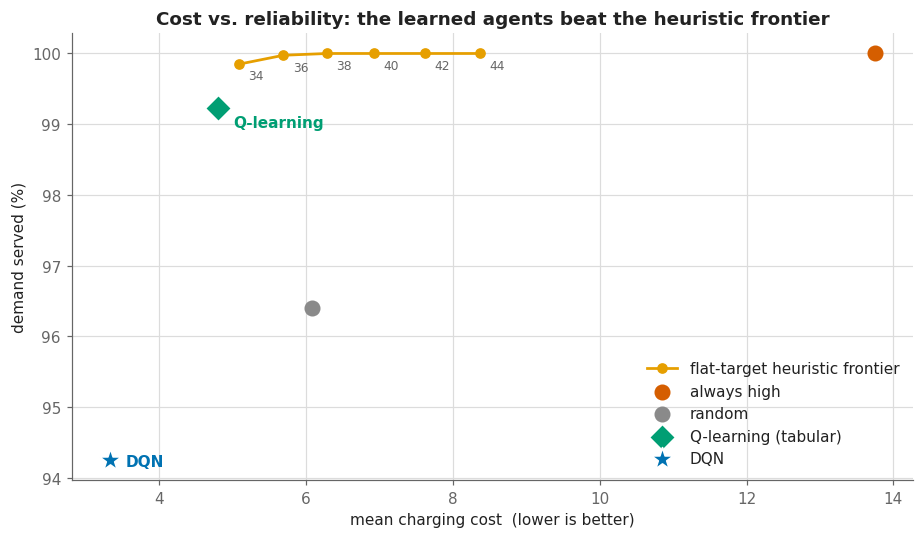

In [28]:
targets = list(range(34, 45, 2))
frontier = [evaluate(make_target_policy(t)) for t in targets]
fx = [v["cost"] for v in frontier]; fy = [v["served"] for v in frontier]

dqn_res = rows["DQN (stable-baselines3)"]
ql_res = rows["Q-learning (tabular)"]
hi = rows["Always high"]; rnd = rows["Random"]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(fx, fy, color=C_FLAT, lw=1.8, marker="o", ms=6, zorder=2,
        label="flat-target heuristic frontier")
for t, x, y in zip(targets, fx, fy):
    ax.annotate(f"{t}", (x, y), textcoords="offset points", xytext=(6, -10),
                fontsize=8, color=MUTED)
ax.scatter([hi["cost"]], [hi["served"]], color=C_HIGH, s=90, zorder=3,
           label="always high")
ax.scatter([rnd["cost"]], [rnd["served"]], color=C_RANDOM, s=90, zorder=3,
           label="random")
ax.scatter([ql_res["cost"]], [ql_res["served"]], color=C_QL, s=150, marker="D",
           zorder=4, edgecolor="white", linewidth=1.2, label="Q-learning (tabular)")
ax.scatter([dqn_res["cost"]], [dqn_res["served"]], color=C_DQN, s=240, marker="*",
           zorder=4, edgecolor="white", linewidth=1.2, label="DQN")
ax.annotate("DQN", (dqn_res["cost"], dqn_res["served"]),
            textcoords="offset points", xytext=(10, -4), color=C_DQN,
            fontweight="bold")
ax.annotate("Q-learning", (ql_res["cost"], ql_res["served"]),
            textcoords="offset points", xytext=(10, -12), color=C_QL,
            fontweight="bold")
ax.set_xlabel("mean charging cost  (lower is better)")
ax.set_ylabel("demand served (%)")
ax.set_title("Cost vs. reliability: the learned agents beat the heuristic frontier")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

## Conclusion

Learning **only from reward** (never told the demand distribution or the price
curve), both agents discover the two economically correct behaviours: they **hedge
the stochastic demand** (a battery buffer above the mean demand, serving ~97–99 %
of days). In the evaluation both beat every
hand-crafted baseline and the flat-target frontier (cheaper and more reliable). Between the two, the **tabular agent is the most reliable**
(≈99 % served) while the **DQN achieves the best mean return and the lowest cost**
(a slightly leaner buffer, generalising across battery levels instead of learning
each kWh bin separately),  and it needs roughly an order of magnitude fewer
episodes thanks to experience replay.

**Possible extensions:** carry leftover energy across days (multi-day episodes);
make demand depend on weekday/weather; add a battery-degradation cost term; model a
shared charging hub with several taxis competing for a capacity-limited
`simpy.Resource` behind the same gym interface; or expose the
continuous power directly with a continuous-control algorithm (DDPG/SAC) from
stable-baselines3.